In [12]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import seaborn as sns

from source.helper.log_experiments import  log_experiments_mlflow

In [13]:
# Load the training dataset used for model development.
work_data = pd.read_csv('../data/processed/train_data.csv')

# Load the independent validation dataset used for final model evaluation.
val_data = pd.read_csv('../data/processed/validation_data.csv')

In [14]:
# Separate the input features from the target variable.
X = work_data.drop(columns=['diabetes'])

# Extract the target variable for model training.
y = work_data['diabetes']

In [15]:
# Split the working dataset into training and test sets.
# Stratify is used to preserve the original class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [16]:
def random_forest_fit(train_data, target_data):
    model = RandomForestClassifier(
    n_estimators=200
)
    model.fit(train_data, target_data)

    return model

In [17]:
model_1 = random_forest_fit(X_train, y_train)

In [18]:
y_pred = model_1.predict(X_test)

In [19]:
print(accuracy_score(y_test, y_pred))

0.970125


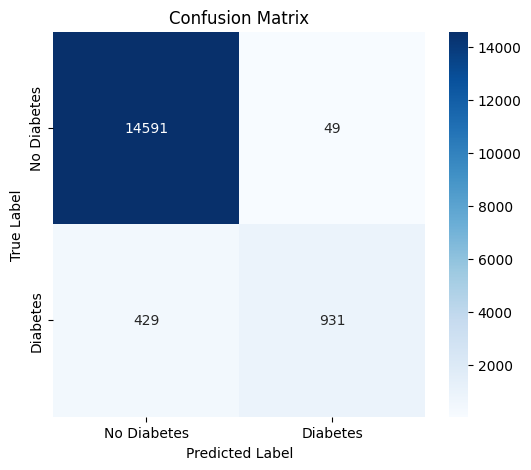

In [20]:
y_pred = model_1.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/model_1_rf_cm.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [32]:
def import_experiment(used_model, experiment_run_name: str) -> None:
    # Log the trained model, its hyperparameters, and evaluation metrics
    # to the specified mlflow experiment for experiment tracking.
    log_experiments_mlflow(
        model=used_model,
        test_dataset=X_test,
        test_target=y_test,
        experiment_name="Diabetes Prediction Based - Clinical and Demographic Features",
        run_name=experiment_run_name
    )

### MLflow Results Analysis

The current model achieves high overall accuracy:

- Accuracy: 0.970125
- Precision: 0.95
- Recall: 0.6845
- F1-score: 0.7957

Although the accuracy is high, the recall is significantly lower than precision. This means that the model is good at correctly identifying positive diabetes cases when it predicts them, but it still misses a notable number of actual positive cases.

### Main Goal

The main goal is to reduce False Negative predictions.

In this project, False Negatives are more critical because they represent people who actually have diabetes, but the model predicts them as non-diabetic. Therefore, the next modeling steps should focus on increasing recall, even if this slightly reduces precision or overall accuracy.

In [25]:
random_forest_tuning_model = RandomForestClassifier()

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=random_forest_tuning_model,
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestClassifier()
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [34]:
first_tuning_random_forest = grid_search.best_estimator_

In [35]:
y_pred = first_tuning_random_forest.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9121875


After the first tuning, the results are decreased significantly

In [36]:
# import_experiment(first_tuning_random_forest, 'RF results after tuning')

Logged run 'RF results after tuning' in experiment 'Diabetes Prediction Based - Clinical and Demographic Features'


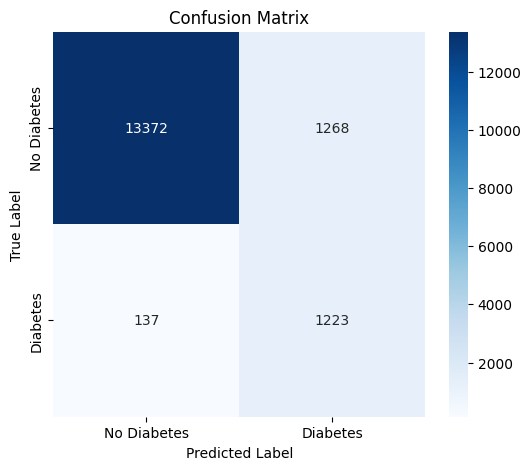

In [37]:
y_pred = first_tuning_random_forest.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/first_tuning_results.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

### Analysis After Random Forest Tuning

After tuning the Random Forest model with `scoring="recall"`, the number of False Negative predictions decreased significantly.

From the confusion matrix:

- True Negatives: 13,372
- False Positives: 1,268
- False Negatives: 137
- True Positives: 1,223

This is a positive result because the model now misses far fewer actual diabetes cases. In this project, reducing False Negatives is very important, because a False Negative means that a person with diabetes is incorrectly classified as non-diabetic.

However, the overall accuracy decreased noticeably. This happens because the model became more sensitive toward the positive class and now predicts more patients as diabetic. As a result, False Positives increased.

### Main Conclusion

The tuning improved recall and reduced False Negatives, which matches the main project goal. However, the drop in accuracy shows that the model is now less balanced overall.